In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.style.use('ggplot')

df = pd.read_csv('train.csv')

In [3]:
rows, cols = df.shape
print(f"\nКоличество строк: {rows}")
print(f"Количество столбцов: {cols}")

print("\nНазвания столбцов:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

print("\nТипы данных столбцов:")
print(df.dtypes)


Количество строк: 891
Количество столбцов: 12

Названия столбцов:
  1. PassengerId
  2. Survived
  3. Pclass
  4. Name
  5. Sex
  6. Age
  7. SibSp
  8. Parch
  9. Ticket
  10. Fare
  11. Cabin
  12. Embarked

Типы данных столбцов:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [4]:
print("\nКоличество пассажиров каждого класса:")
class_counts = df['Pclass'].value_counts().sort_index()
for pclass, count in class_counts.items():
    print(f"   {pclass} класс: {count} пассажиров")


1. Количество пассажиров каждого класса:
   1 класс: 216 пассажиров
   2 класс: 184 пассажиров
   3 класс: 491 пассажиров


In [5]:
print("\nКоличество мужчин и женщин:")
sex_counts = df['Sex'].value_counts()
for sex, count in sex_counts.items():
    print(f"   {sex}: {count} пассажиров")


2. Количество мужчин и женщин:
   male: 577 пассажиров
   female: 314 пассажиров


In [7]:
print("\nРазделение пассажиров на возрастные группы:")
bins = [0, 12, 18, 30, 50, 100]
labels = ['Дети (0-12)', 'Подростки (13-18)', 'Молодые (19-30)', 
          'Взрослые (31-50)', 'Пожилые (51+)']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
age_group_counts = df['AgeGroup'].value_counts().sort_index()
for group, count in age_group_counts.items():
    print(f"   {group}: {count} пассажиров")


3. Разделение пассажиров на возрастные группы:
   Дети (0-12): 69 пассажиров
   Подростки (13-18): 70 пассажиров
   Молодые (19-30): 270 пассажиров
   Взрослые (31-50): 241 пассажиров
   Пожилые (51+): 64 пассажиров


In [8]:
mean_age = df['Age'].mean()
print(f"\nСредний возраст пассажиров: {mean_age:.2f} лет")

median_age = df['Age'].median()
print(f"Медианный возраст пассажиров: {median_age:.2f} лет")

mean_fare = df['Fare'].mean()
print(f"Средняя стоимость билета: {mean_fare:.2f}")


Средний возраст пассажиров: 29.70 лет
Медианный возраст пассажиров: 28.00 лет
Средняя стоимость билета: 32.20


In [17]:
print("\nСредняя стоимость билета по классам:")
fare_by_class = df.groupby('Pclass')['Fare'].mean()
for pclass, fare in fare_by_class.items():
    print(f"   {pclass} класс: {fare:.2f}")


Средняя стоимость билета по классам:
   1 класс: 84.15
   2 класс: 20.66
   3 класс: 13.68


In [18]:
print("\nСредний возраст пассажиров по классам:")
age_by_class = df.groupby('Pclass')['Age'].mean()
for pclass, age in age_by_class.items():
    print(f"   {pclass} класс: {age:.2f} лет")


Средний возраст пассажиров по классам:
   1 класс: 38.23 лет
   2 класс: 29.88 лет
   3 класс: 25.14 лет


In [19]:
print("\nКоличество мужчин и женщин в каждом классе:")
sex_by_class = df.groupby(['Pclass', 'Sex']).size().unstack(fill_value=0)
print(sex_by_class)


Количество мужчин и женщин в каждом классе:
Sex     female  male
Pclass              
1           94   122
2           76   108
3          144   347


In [20]:
print("\nКласс с наибольшим количеством пассажиров:")
max_class = class_counts.idxmax()
max_count = class_counts.max()
print(f"   {max_class} класс — {max_count} пассажиров")


Класс с наибольшим количеством пассажиров:
   3 класс — 491 пассажиров


In [21]:
print("\nВывод о различиях между классами:")
print("    1-й класс: самые дорогие билеты, пассажиры старшего возраста")
print("    2-й класс: средняя стоимость билетов и возраст")
print("    3-й класс: самые дешёвые билеты, преобладают молодые пассажиры")
print("    В 3-м классе больше всего пассажиров, в 1-м — меньше всего")


Вывод о различиях между классами:
    1-й класс: самые дорогие билеты, пассажиры старшего возраста
    2-й класс: средняя стоимость билетов и возраст
    3-й класс: самые дешёвые билеты, преобладают молодые пассажиры
    В 3-м классе больше всего пассажиров, в 1-м — меньше всего


In [22]:
print("\nИнформация о самом дорогом билете:")
most_expensive_idx = df['Fare'].idxmax()
most_expensive = df.loc[most_expensive_idx]
print(f"   Стоимость: {most_expensive['Fare']}")
print(f"   Класс: {most_expensive['Pclass']}")
print(f"   Возраст: {most_expensive['Age']}")
print(f"   Пол: {most_expensive['Sex']}")
print(f"   Выжил: {'Да' if most_expensive['Survived'] == 1 else 'Нет'}")
print(f"   Имя: {most_expensive['Name']}")


Информация о самом дорогом билете:
   Стоимость: 512.3292
   Класс: 1
   Возраст: 35.0
   Пол: female
   Выжил: Да
   Имя: Ward, Miss. Anna


In [23]:
print("\nОбщее количество выживших и погибших:")
survived_counts = df['Survived'].value_counts()
print(f"   Погибли (0): {survived_counts[0]} человек")
print(f"   Выжили (1): {survived_counts[1]} человек")
print(f"   Общая доля выживших: {df['Survived'].mean() * 100:.1f}%")


Общее количество выживших и погибших:
   Погибли (0): 549 человек
   Выжили (1): 342 человек
   Общая доля выживших: 38.4%


In [25]:
print("\nВыживаемость мужчин и женщин:")
survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100
for sex, rate in survival_by_sex.items():
    print(f"   {sex}: {rate:.1f}%")


Выживаемость мужчин и женщин:
   female: 74.2%
   male: 18.9%


In [27]:
print("\nВыживаемость по полу и классу:")
survival_by_class_sex = df.groupby(['Pclass', 'Sex'])['Survived'].mean() * 100
for (pclass, sex), rate in survival_by_class_sex.items():
    print(f"   {pclass} класс, {sex}: {rate:.1f}%")


Выживаемость по полу и классу:
   1 класс, female: 96.8%
   1 класс, male: 36.9%
   2 класс, female: 92.1%
   2 класс, male: 15.7%
   3 класс, female: 50.0%
   3 класс, male: 13.5%


In [34]:
print("\nГруппа с наибольшей долей выживших:")
best_group = survival_by_class_sex.idxmax()
best_rate = survival_by_class_sex.max()
print(f"   {best_group[0]} класс, {best_group[1]}: {best_rate:.1f}% выживших")


Группа с наибольшей долей выживших:
   1 класс, female: 96.8% выживших


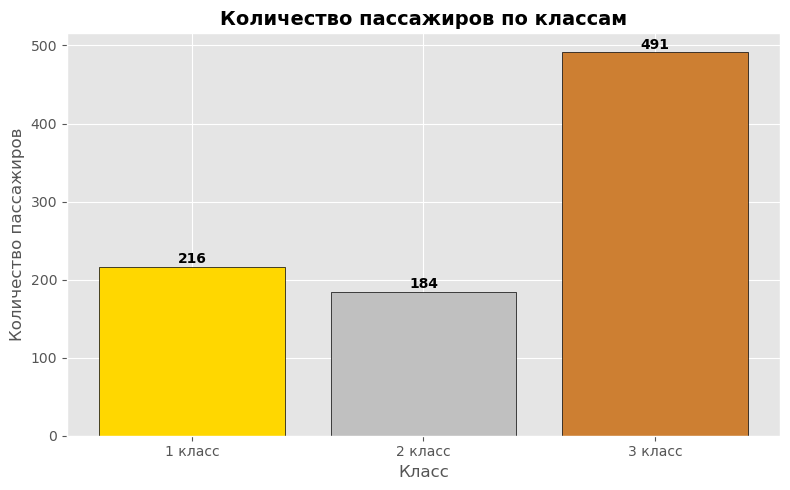

In [35]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#FFD700', '#C0C0C0', '#CD7F32']  # золото, серебро, бронза

bars = ax.bar(class_counts.index, class_counts.values, color=colors, edgecolor='black')
ax.set_title('Количество пассажиров по классам', fontsize=14, fontweight='bold')
ax.set_xlabel('Класс')
ax.set_ylabel('Количество пассажиров')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['1 класс', '2 класс', '3 класс'])

for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('passengers_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

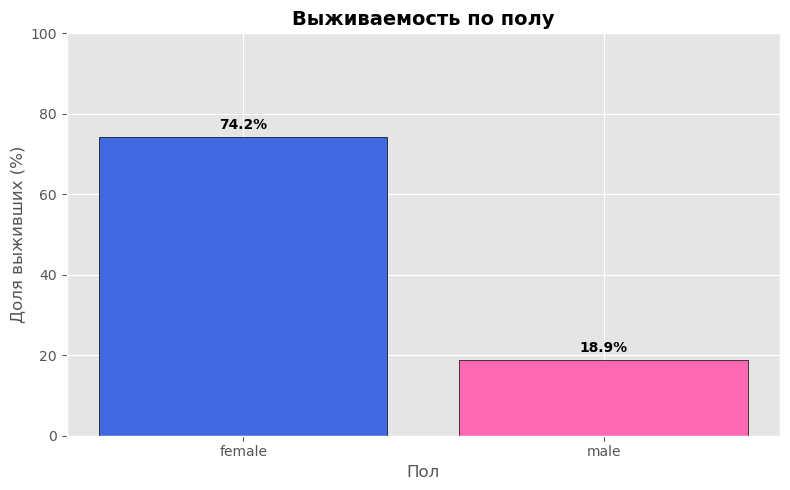

In [36]:
sex_survival = df.groupby('Sex')['Survived'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(sex_survival.index, sex_survival.values,
              color=['#4169E1', '#FF69B4'], edgecolor='black')

ax.set_title('Выживаемость по полу', fontsize=14, fontweight='bold')
ax.set_xlabel('Пол')
ax.set_ylabel('Доля выживших (%)')
ax.set_ylim(0, 100)

for bar, rate in zip(bars, sex_survival.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{rate:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('survival_by_sex.png', dpi=150, bbox_inches='tight')
plt.show()